<a href="https://colab.research.google.com/github/mmanishyadav325-ux/ubiquitous-couscous/blob/main/Level3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LEVEL 3**

# **TASK 1**



# **Task: Restaurant Reviews**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"/content/Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
print(df["Rating text"])

0       Excellent
1       Excellent
2       Very Good
3       Excellent
4       Excellent
          ...    
9546    Very Good
9547    Very Good
9548         Good
9549    Very Good
9550    Very Good
Name: Rating text, Length: 9551, dtype: object


# Analyze the text reviews to identify the most common positiveand negative keywords.

In [ ]:
positive_data=df.loc[df['Aggregate rating']>=2.5]
print(positive_data)

      Restaurant ID           Restaurant Name  Country Code              City  \
0           6317637          Le Petit Souffle           162       Makati City   
1           6304287          Izakaya Kikufuji           162       Makati City   
2           6300002    Heat - Edsa Shangri-La           162  Mandaluyong City   
3           6318506                      Ooma           162  Mandaluyong City   
4           6314302               Sambo Kojin           162  Mandaluyong City   
...             ...                       ...           ...               ...   
9546        5915730               Naml۱ Gurme           208         ��stanbul   
9547        5908749              Ceviz A��ac۱           208         ��stanbul   
9548        5915807                     Huqqa           208         ��stanbul   
9549        5916112               A���k Kahve           208         ��stanbul   
9550        5927402  Walter's Coffee Roastery           208         ��stanbul   

                           

In [ ]:
positive_keywords=positive_data["Rating text"]
print(positive_keywords)


0       Excellent
1       Excellent
2       Very Good
3       Excellent
4       Excellent
          ...    
9546    Very Good
9547    Very Good
9548         Good
9549    Very Good
9550    Very Good
Name: Rating text, Length: 7217, dtype: object


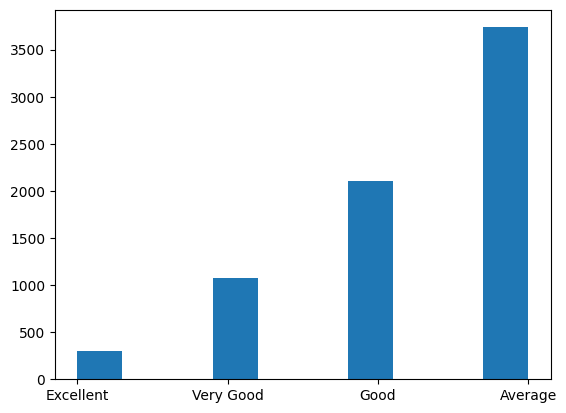

In [ ]:
positive_data=df.loc[df['Aggregate rating']>=2.5]
positive_keywords=positive_data["Rating text"]
plt.hist(positive_data['Rating text'], label='Positive Rating Texts')
plt.show()

In [ ]:
negative_data=df.loc[(df['Aggregate rating']<2.5) & (df['Aggregate rating']>0)]
negative_keywords=negative_data["Rating text"].unique()
print(negative_keywords)

['Poor']


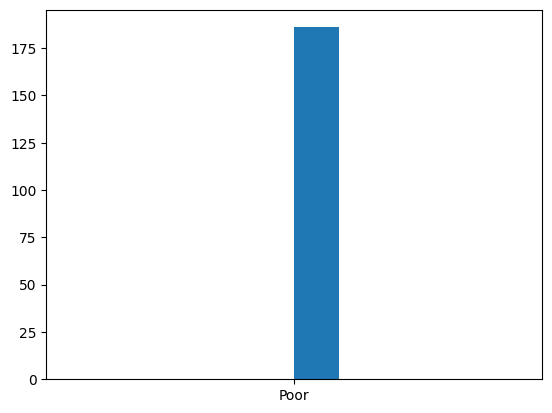

In [ ]:
negative_data=df.loc[(df['Aggregate rating']<2.5) & (df['Aggregate rating']>0)]
negative_keywords=negative_data["Rating text"].unique()
plt.hist(negative_data['Rating text'], label='Negative Rating Texts')
plt.show()

# **Task 2**

# **Task: Votes Analysis**

# Identify the restaurants with the highest and lowest number of votes.

In [ ]:
Highest_voted_restaurant=df.groupby('Restaurant Name')['Votes'].sum().sort_values(ascending=False)
Highest_voted_restaurant_name=Highest_voted_restaurant.idxmax()
Lowest_voted_restaurant=df.groupby('Restaurant Name')['Votes'].sum().sort_values(ascending=True)
Lowest_voted_restaurant_name=Lowest_voted_restaurant.idxmin()
print("The Highest Votes Restaurant is :", Highest_voted_restaurant_name)
print("The Lowest Votes Restaurant is :", Lowest_voted_restaurant_name)

The Highest Votes Restaurant is : Barbeque Nation
The Lowest Votes Restaurant is : Breaky2Dinner


# Analyze if there is a correlation between thenumber of votes and the rating of a restaurant.

In [ ]:
correlation=np.corrcoef(df['Votes'], df['Aggregate rating'])[0, 1]
correlation=np.round(correlation, 2)
print(correlation)

0.31


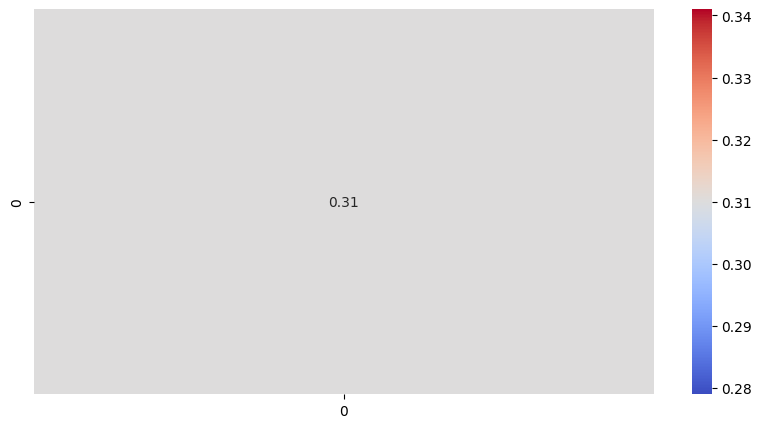

In [ ]:
plt.figure(figsize=(10, 5),dpi=100)
sns.heatmap(np.array([[correlation]]), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

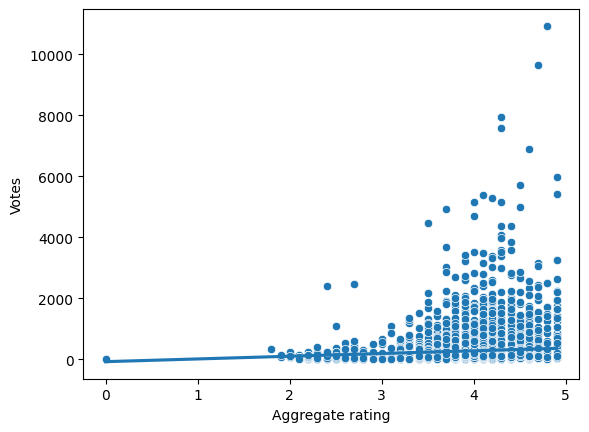

 As per result corelation value =0.31,which indicates there is a noderate positive corelation  between these  two  variable  


In [ ]:

sns.scatterplot(data=df, y='Votes', x='Aggregate rating')
sns.regplot(data=df,x='Aggregate rating',y='Votes',scatter=False)
plt.show()
print(" As per result corelation value =0.31,which indicates there is a noderate positive corelation  between these  two  variable  ")

# **Task 3**

# **Task: Price Range Vs Online Delivery and Table Booking**

# **Analyze if there is a relationship between the price range and the availability of online delivery**

To analyze this we need to plot 2 chart together

In [ ]:

x1=df['Has Online delivery']
y=df['Average Cost for two']
x2=df['Has Table booking']

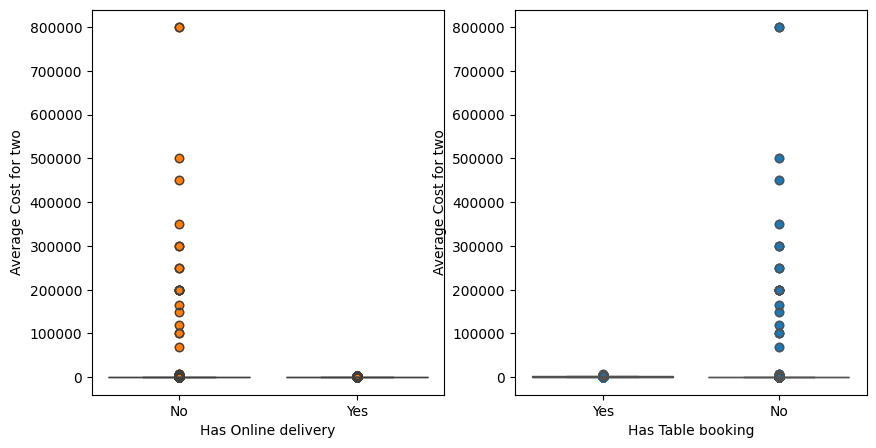

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5),dpi=100)
plt.subplot(1,2,1)
sns.boxplot(x=x1,y=y)

plt.scatter(x1,y)
plt.xlabel('Has Online delivery')
plt.ylabel('Average Cost for two')
plt.subplot(1,2,2)
plt.scatter(x2,y)
sns.boxplot(x=x2,y=y)
plt.xlabel('Has Table booking')
plt.ylabel('Average Cost for two')
plt.show()

In [ ]:
print("both the Online delivery and Tablr booking are negetively impacted by the cost")

both the Online delivery and Tablr booking are negetively impacted by the cost


# **Determine if higher -price restaurant are more likely to offer these  services.**

In [ ]:
print('High priced Restaurants which have average cost more than 10,000 did not provide Online delivery as Well as Table Booking facilited')

High priced Restaurants which have average cost more than 10,000 did not provide Online delivery as Well as Table Booking facilited


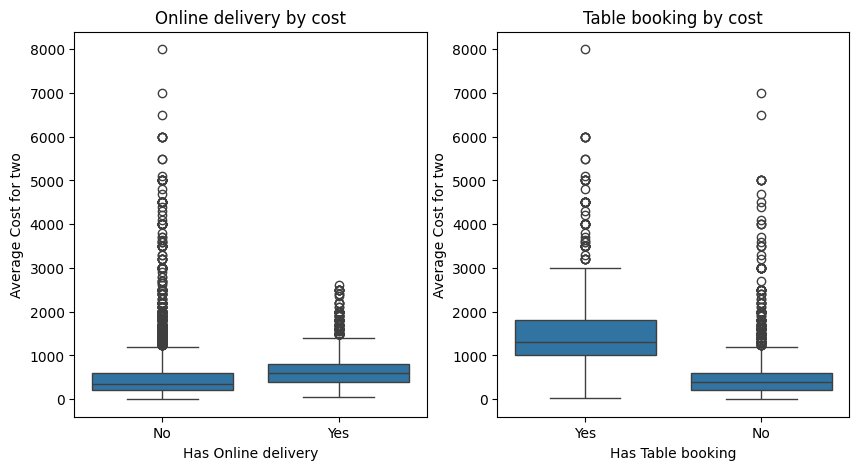

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 5),dpi=100)
plt.subplot(1,2,1)
sns.boxplot(x=x1,y="Average Cost for two",data=df[df['Average Cost for two']<10000])
plt.title("Online delivery by cost")
plt.subplot(1,2,2)
sns.boxplot(x=x2,y="Average Cost for two",data=df[df['Average Cost for two']<10000])
plt.title("Table booking by cost")
plt.show()
plt.tight_layout()

In [ ]:
print("The Online delivery facility is present for only those restaurant ,where the avg cost is less than 1000")
print(" The Table booking facility is available in reasaurants with an avaeage cost ranging from 1000 to 2000 ")

The Online delivery facility is present for only those restaurant ,where the avg cost is less than 1000
 The Table booking facility is available in reasaurants with an avaeage cost ranging from 1000 to 2000 
